In [1]:
!pip install opendatasets
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=538b1a266a865c0236872b95d56c6a2bb064e7dd92fd4b677d1ee7847cde9d7e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import opendatasets as od
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support


# **Load & Prepare Data**

In [3]:
ham_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
isic_url = "https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic"

print("Downloading HAM10000...")
od.download(ham_url)
print("Downloading ISIC 9 Classes...")
od.download(isic_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Bassant
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [04:02<00:00, 23.1MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Bassant
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic


100%|██████████| 786M/786M [00:48<00:00, 16.9MB/s]


In [4]:
master_dir = 'unified_dataset'
os.makedirs(master_dir, exist_ok=True)

ham_mapping = {'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
               'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
               'vasc': 'vascular_lesion'}

isic_mapping = {'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
                'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
                'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
                'squamous cell carcinoma': 'actinic_keratosis', 'vascular lesion': 'vascular_lesion'}

ham_base = 'skin-cancer-mnist-ham10000'
metadata = pd.read_csv(f'{ham_base}/HAM10000_metadata.csv')
ham_folders = [f'{ham_base}/ham10000_images_part_1', f'{ham_base}/ham10000_images_part_2']


print("Processing HAM10000...")
for _, row in metadata.iterrows():
    label = ham_mapping[row['dx']]
    dest = os.path.join(master_dir, label)
    os.makedirs(dest, exist_ok=True)
    img_name = row['image_id'] + '.jpg'
    for folder in ham_folders:
        src = os.path.join(folder, img_name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest, img_name))
            break

print("Processing ISIC 9 Classes...")
isic_root = 'skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
for split in ['Train', 'Test']:
    split_path = os.path.join(isic_root, split)
    if not os.path.exists(split_path): continue
    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            dest_folder = os.path.join(master_dir, target_label)
            os.makedirs(dest_folder, exist_ok=True)
            src_folder = os.path.join(split_path, folder_name)
            for img in os.listdir(src_folder):
                safe_img_name = f"isic9_{split.lower()}_{img}"
                shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, safe_img_name))

classes = sorted(os.listdir(master_dir))
print(f'\nUnified dataset — {len(classes)} classes:')
total = 0
for c in classes:
    n = len(os.listdir(os.path.join(master_dir, c)))
    total += n
    print(f'  {c:30s}: {n:6d} images')
print(f'  {"TOTAL":30s}: {total:6d} images')

Processing HAM10000...
Processing ISIC 9 Classes...

Unified dataset — 7 classes:
  actinic_keratosis             :    654 images
  basal_cell_carcinoma          :    906 images
  benign_keratosis              :   1657 images
  dermatofibroma                :    226 images
  melanocytic_nevi              :   7078 images
  melanoma                      :   1567 images
  vascular_lesion               :    284 images
  TOTAL                         :  12372 images


In [5]:
df = pd.read_csv("skin-cancer-mnist-ham10000/HAM10000_metadata.csv")
print(df.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [6]:
print('Metadata shape:', df.shape)
print(df[['image_id','dx','age','sex','localization']].head())
print('\nMissing values:')
print(df[['age','sex','localization']].isnull().sum())

Metadata shape: (10015, 7)
       image_id   dx   age   sex localization
0  ISIC_0027419  bkl  80.0  male        scalp
1  ISIC_0025030  bkl  80.0  male        scalp
2  ISIC_0026769  bkl  80.0  male        scalp
3  ISIC_0025661  bkl  80.0  male        scalp
4  ISIC_0031633  bkl  75.0  male          ear

Missing values:
age             57
sex              0
localization     0
dtype: int64


In [7]:
df['label'] = df['dx'].map(ham_mapping)

In [8]:
from sklearn.preprocessing import StandardScaler
df['age'] = df['age'].fillna(df['age'].median())
scaler = StandardScaler()
df['age_norm'] = scaler.fit_transform(df[['age']])

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex_enc'] = le.fit_transform(df['sex'])

In [10]:
loc_ohe  = pd.get_dummies(df['localization'].fillna('unknown'), prefix='loc')

In [11]:
df = pd.concat([df, loc_ohe], axis=1)
meta_cols = ['age_norm', 'sex_enc'] + [c for c in df.columns if c.startswith('loc_')]
META_DIM  = len(meta_cols)
print(f'Metadata feature vector dimension: {META_DIM}')
print(df[meta_cols].head())

Metadata feature vector dimension: 17
   age_norm  sex_enc  loc_abdomen  loc_acral  loc_back  loc_chest  loc_ear  \
0  1.663522        1        False      False     False      False    False   
1  1.663522        1        False      False     False      False    False   
2  1.663522        1        False      False     False      False    False   
3  1.663522        1        False      False     False      False    False   
4  1.368014        1        False      False     False      False     True   

   loc_face  loc_foot  loc_genital  loc_hand  loc_lower extremity  loc_neck  \
0     False     False        False     False                False     False   
1     False     False        False     False                False     False   
2     False     False        False     False                False     False   
3     False     False        False     False                False     False   
4     False     False        False     False                False     False   

   loc_scalp  loc_

# **Data Preprocessing**

In [12]:
def remove_hair(img):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY),
                                 cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    inpainted = cv2.inpaint(img, thresh, 1, cv2.INPAINT_TELEA)
    return inpainted

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq  = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)

def preprocess_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = remove_hair(img)
    img = apply_clahe(img)
    img = cv2.resize(img, target_size)
    return img.astype(np.float32) / 255.0


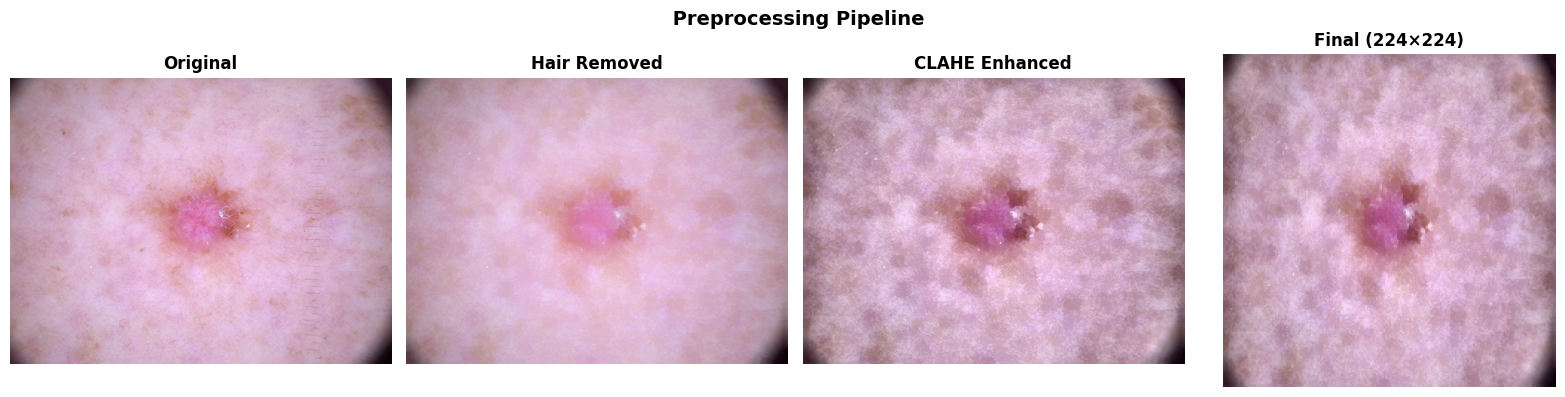

In [13]:
sample_class = classes[3]
sample_img_path = os.path.join(master_dir, sample_class,
                               os.listdir(os.path.join(master_dir, sample_class))[0])

img_raw   = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
img_hair  = remove_hair(img_raw)
img_clahe = apply_clahe(img_hair)
img_final = cv2.resize(img_clahe, (224, 224))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'Hair Removed', 'CLAHE Enhanced', 'Final (224×224)']
for ax, im, t in zip(axes, [img_raw, img_hair, img_clahe, img_final], titles):
    ax.imshow(im)
    ax.set_title(t, fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle(' Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
train_dir = 'train_dataset'
val_dir   = 'val_dataset'
test_dir  = 'test_dataset'

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

for cls in classes:
    cls_path = os.path.join(master_dir, cls)
    images   = os.listdir(cls_path)
    random.shuffle(images)

    n         = len(images)
    n_test    = max(1, int(n * 0.15))
    n_val     = max(1, int(n * 0.15))
    n_train   = n - n_test - n_val

    splits = {'train': images[:n_train],
              'val':   images[n_train:n_train+n_val],
              'test':  images[n_train+n_val:]}

    for split_name, split_dir in [('train', train_dir),
                                   ('val',   val_dir),
                                   ('test',  test_dir)]:
        dest = os.path.join(split_dir, cls)
        os.makedirs(dest, exist_ok=True)
        for img in splits[split_name]:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(dest, img))

def oversample_to_max(split_dir):
    class_counts = {c: len(os.listdir(os.path.join(split_dir, c)))
                    for c in os.listdir(split_dir)
                    if os.path.isdir(os.path.join(split_dir, c))}
    max_count = max(class_counts.values())
    for cls, count in class_counts.items():
        if count < max_count:
            cls_path = os.path.join(split_dir, cls)
            imgs     = os.listdir(cls_path)
            needed   = max_count - count
            for i in range(needed):
                src = os.path.join(cls_path, random.choice(imgs))
                dst = os.path.join(cls_path, f'os_{i}_{os.path.basename(src)}')
                if not os.path.exists(dst):
                    shutil.copy(src, dst)

oversample_to_max(train_dir)

print('Split summary:')
for d, name in [(train_dir, 'Train'), (val_dir, 'Val'), (test_dir, 'Test')]:
    tot = sum(len(os.listdir(os.path.join(d, c)))
              for c in os.listdir(d) if os.path.isdir(os.path.join(d, c)))
    print(f'  {name}: {tot} images')

Split summary:
  Train: 34692 images
  Val: 1852 images
  Test: 1852 images


# **Data Augmentation**

In [15]:
SEED = 42
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED)

val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)
print('Train batches:', len(train_gen))

Found 34692 images belonging to 7 classes.
Found 1852 images belonging to 7 classes.
Found 1852 images belonging to 7 classes.
Classes: ['actinic_keratosis', 'basal_cell_carcinoma', 'benign_keratosis', 'dermatofibroma', 'melanocytic_nevi', 'melanoma', 'vascular_lesion']
Train batches: 1085


# **EDA**

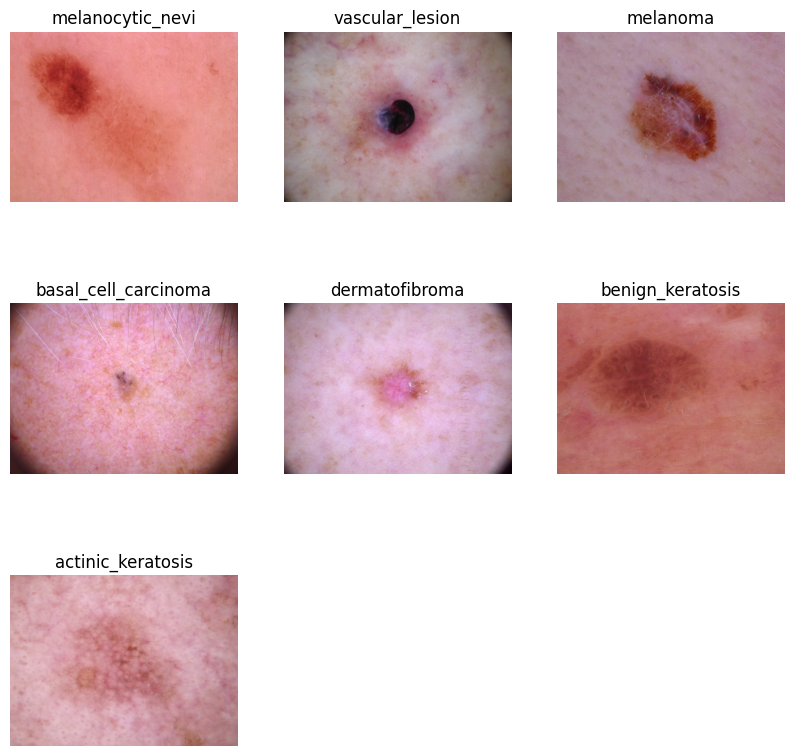

In [16]:
base = "unified_dataset"

plt.figure(figsize=(10,10))

i = 1
for cls in os.listdir(base):
    img_path = os.path.join(base, cls, os.listdir(os.path.join(base, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i)
    plt.title(cls)
    plt.imshow(img)
    plt.axis('off')
    i += 1

plt.show()

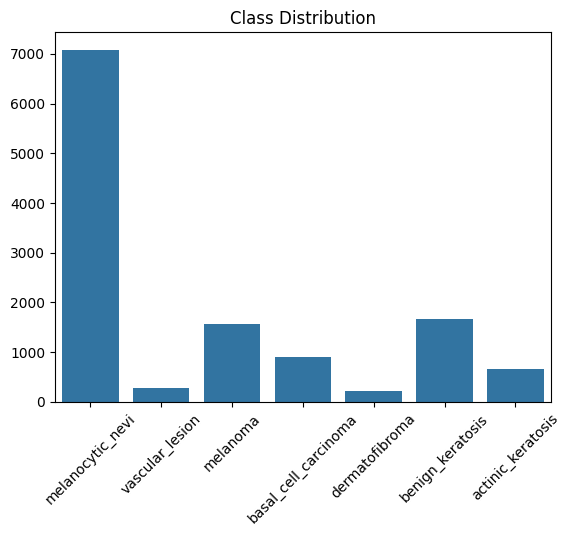

In [17]:
counts = []
labels = []

for cls in os.listdir("unified_dataset"):
    count = len(os.listdir(os.path.join("unified_dataset", cls)))
    counts.append(count)
    labels.append(cls)

sns.barplot(x=labels, y=counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

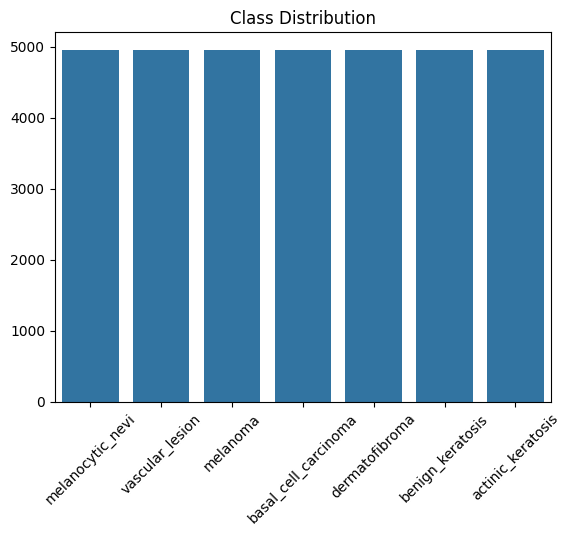

In [18]:
counts = []
labels = []

for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    counts.append(count)
    labels.append(cls)

sns.barplot(x=labels, y=counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

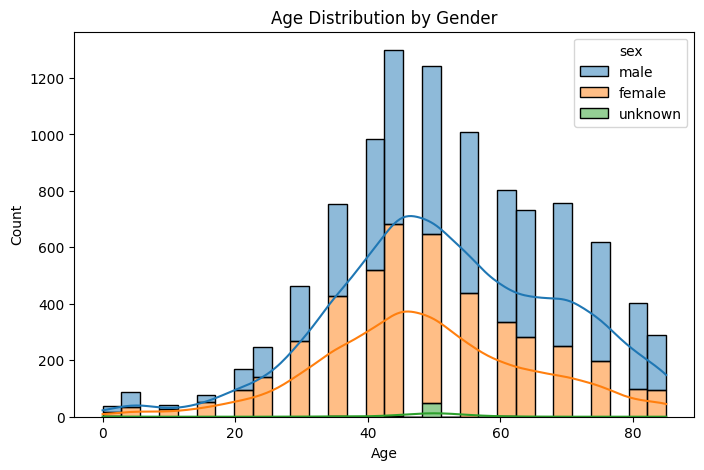

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="sex",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1786/1966159067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='pastel', ax=ax)


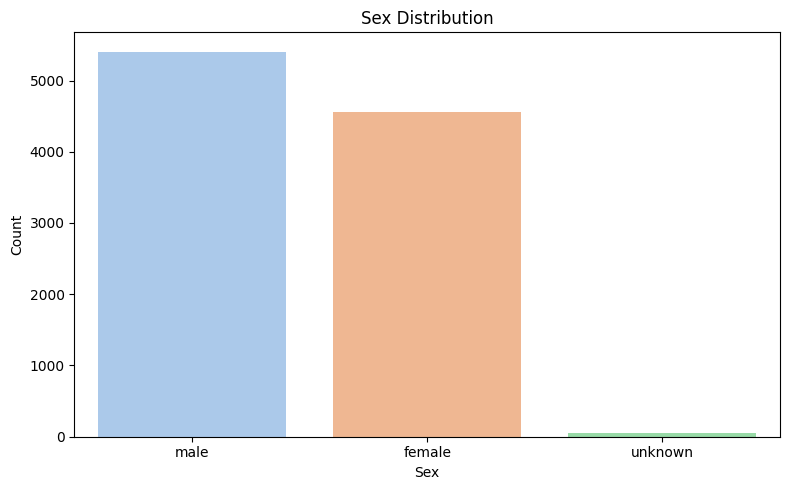

In [20]:
gender_counts = df['sex'].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.countplot(data=df, x='sex', palette='pastel', ax=ax)
ax.set_title('Sex Distribution')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

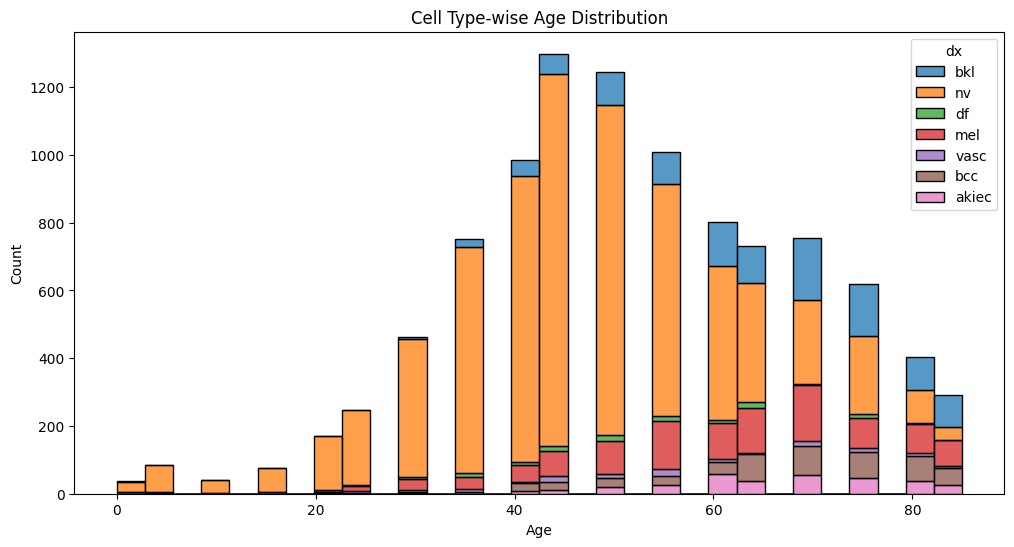

In [21]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="age",
    hue="dx",
    bins=30,
    multiple="stack"
)

plt.title("Cell Type-wise Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_1786/718368662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


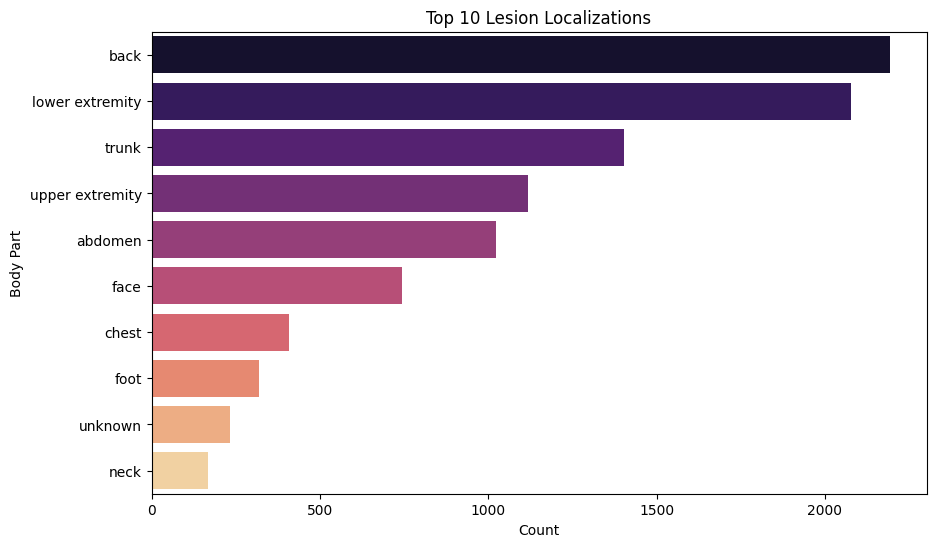

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
top_locations = df['localization'].value_counts().nlargest(10).index
sns.countplot(
    data=df[df['localization'].isin(top_locations)],
    y='localization',
    order=top_locations,
    palette='magma',
    ax=ax)
ax.set_title('Top 10 Lesion Localizations')
ax.set_xlabel('Count')
ax.set_ylabel('Body Part')


plt.show()

/tmp/ipykernel_1786/1456870675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age', y='dx', palette='Set2')


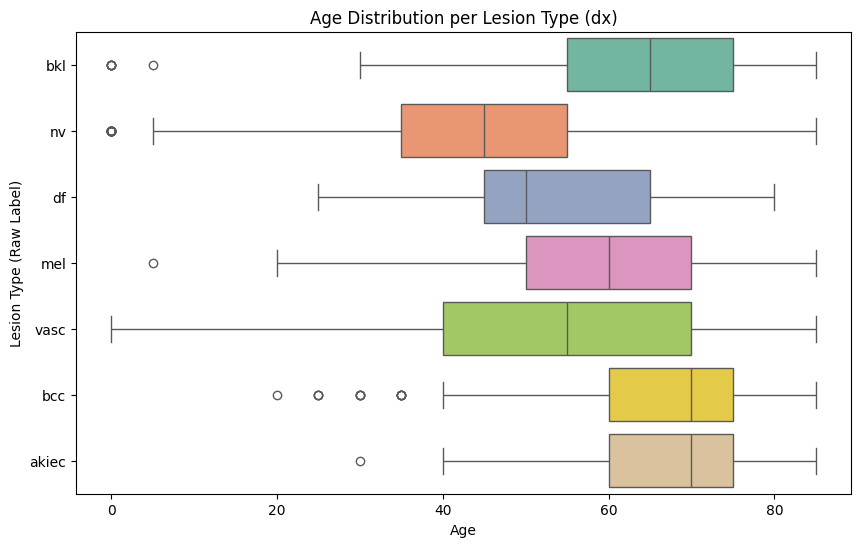

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='age', y='dx', palette='Set2')
plt.title('Age Distribution per Lesion Type (dx)')
plt.xlabel('Age')
plt.ylabel('Lesion Type (Raw Label)')
plt.show()

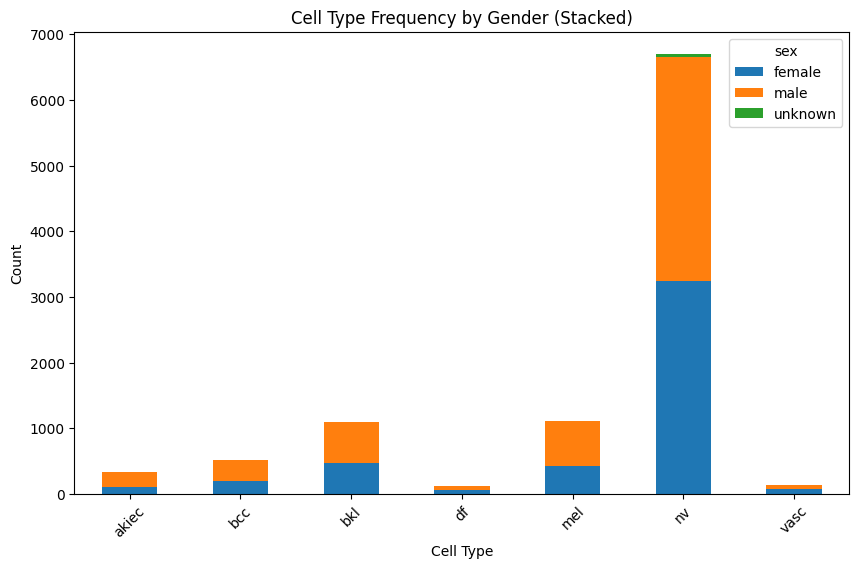

In [24]:
table = pd.crosstab(df['dx'], df['sex'])

table.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Cell Type Frequency by Gender (Stacked)")
plt.xlabel("Cell Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

# **Model Implementation**

In [36]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax


def build_optimized_cnn(input_shape=(224, 224, 3),classes=7):
    image_input = Input( shape=input_shape,name='image_input')

    x = Conv2D(32,(3,3),padding='same')(image_input)

    x = Activation('swish')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3,3), padding='same')(x)

    x = Activation('swish')(x)
    x = BatchNormalization()(x)

    x = MaxPooling2D((2,2))(x)

    x = Dropout(0.25)(x)

    x = Conv2D(64,(3,3),padding='same')(x)
    x = Activation('swish')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64,(3,3),padding='same')(x)
    x = Activation('swish')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(128,(3,3),padding='same',name='last_conv_layer')(x)
    x = Activation('swish')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.30)(x)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='swish')(x)
    x = Dropout(0.4)(x)
    x = Dense(128,activation='swish')(x)

    x = Dropout(0.3)(x)

    output = Dense(classes,activation='softmax', name='output' )(x)

    model = Model(
        inputs=image_input,
        outputs=output,
        name='OptimizedCNN'
    )

    model.compile(
        optimizer=Adamax(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_optimized_cnn(
    input_shape=(224,224,3),
    classes=NUM_CLASSES
)

model.summary()

Model: "OptimizedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 207,527 (810.65 KB)

 Trainable params: 206,887 (808.15 KB)

 Non-trainable params: 640 (2.50 KB)

In [1]:
callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint('best_model_phase1.h5', monitor='val_accuracy',
                    save_best_only=True, mode='max')
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_p1
)

NameError: name 'EarlyStopping' is not defined

# **Evaluation**

In [33]:
y_pred_probs = model.predict(mm_test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array([s[1] for s in mm_test_gen.samples])
class_names = CLASS_NAMES

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 367ms/step


In [34]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.34773218142548595
                      precision    recall  f1-score   support

   actinic_keratosis       0.07      0.11      0.09        98
basal_cell_carcinoma       0.09      0.07      0.08       135
    benign_keratosis       0.11      0.12      0.11       248
      dermatofibroma       0.03      0.06      0.04        33
    melanocytic_nevi       0.55      0.54      0.55      1061
            melanoma       0.10      0.08      0.09       235
     vascular_lesion       0.00      0.00      0.00        42

            accuracy                           0.35      1852
           macro avg       0.14      0.14      0.14      1852
        weighted avg       0.35      0.35      0.35      1852



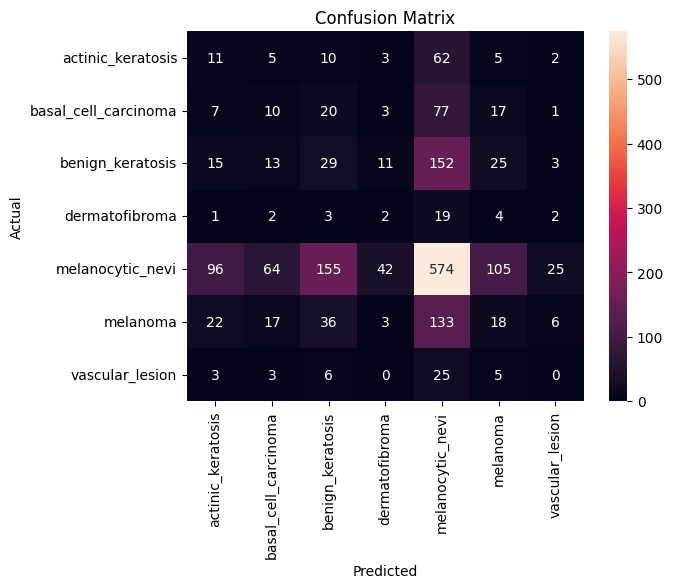

In [35]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

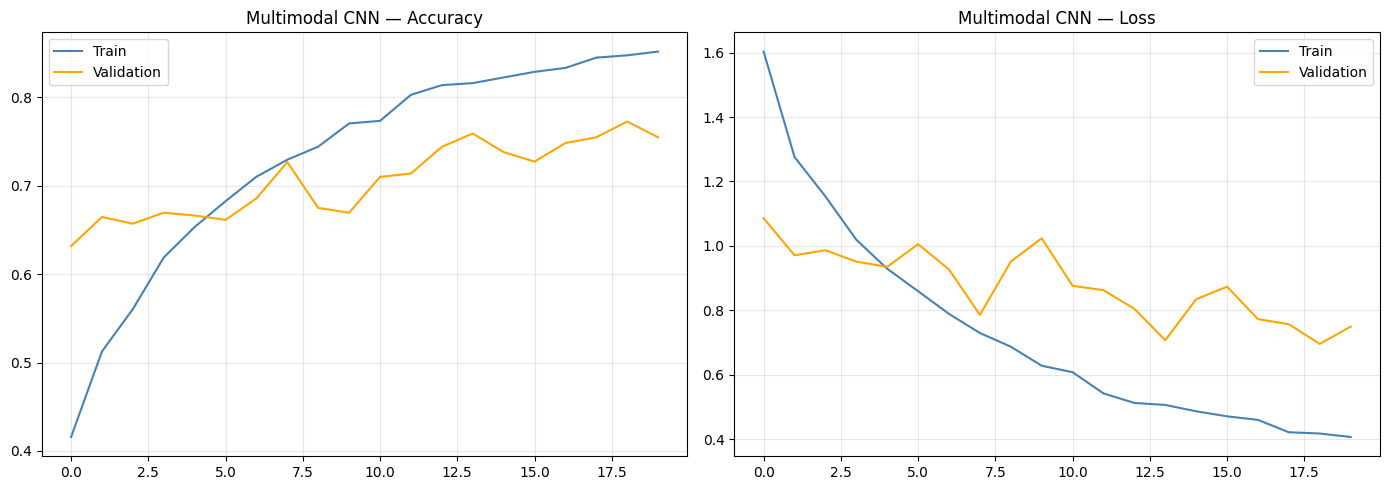

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Multimodal CNN — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Multimodal CNN — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
all_imgs, all_tabs, all_labels = [], [], []
for [imgs_b, tabs_b] in test_gen:
    all_imgs.append(imgs_b); all_tabs.append(tabs_b); all_labels.append(lbls_b)
all_imgs   = np.concatenate(all_imgs)
all_tabs   = np.concatenate(all_tabs)
y_true     = np.argmax(np.concatenate(all_labels), axis=1)

y_pred_probs = model.predict([all_imgs, all_tabs], verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
print(f'\nMultimodal CNN Test Accuracy: {acc:.4f}')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


NameError: name 'lbls_b' is not defined

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Multimodal DCNN — Confusion Matrix')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.show()

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer_lime = lime_image.LimeImageExplainer()

def predict_fn_lime(images):
    images = images.astype('float32') / 255.0
    return model.predict([images, tab_zeros], verbose=0)

n_lime = 6
fig, axes = plt.subplots(n_lime, 3, figsize=(12, 4*n_lime))

for i in range(n_lime):
    img = (all_imgs[i] * 255).astype(np.uint8)
    true_label = CLASS_NAMES[y_true[i]]
    pred_label = CLASS_NAMES[y_pred[i]]
    pred_conf  = y_pred_probs[i][y_pred[i]]

    explanation = explainer_lime.explain_instance(
        img, predict_fn_lime,
        labels=(y_pred[i],),
        hide_color=0, num_samples=2000
    )
    temp, mask = explanation.get_image_and_mask(
        y_pred[i], positive_only=True, num_features=8, hide_rest=False
    )

    axes[i][0].imshow(all_imgs[i])
    axes[i][0].set_title(f'Original\nTrue: {true_label}', fontsize=8); axes[i][0].axis('off')

    axes[i][1].imshow(mark_boundaries(temp/255.0, mask))
    axes[i][1].set_title(f'LIME\nPred: {pred_label} ({pred_conf:.2f})', fontsize=8); axes[i][1].axis('off')

    axes[i][2].imshow(mask, cmap='hot')
    axes[i][2].set_title('LIME Mask', fontsize=8); axes[i][2].axis('off')

fig.suptitle('XAI Method 1: LIME — Multimodal DCNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('LIME done!')

In [ ]:
def get_gradcam(model, img_array, tab_array, pred_index=None):
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv = layer; break

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([img_array, tab_array], training=False)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_cam(img, heatmap, alpha=0.4):
    h = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    colored = (mplcm.jet(h)[:,:,:3] * 255).astype(np.uint8)
    base    = (img * 255).astype(np.uint8)
    return cv2.addWeighted(base, 1-alpha, colored, alpha, 0)


n_gcam = 6
fig, axes = plt.subplots(n_gcam, 3, figsize=(12, 4*n_gcam))

for i in range(n_gcam):
    img  = all_imgs[i]
    tab  = all_tabs[i:i+1]
    img_b = img[np.newaxis]

    heatmap = get_gradcam(model, img_b, tab)
    overlay = overlay_cam(img, heatmap)

    axes[i][0].imshow(img)
    axes[i][0].set_title(f'Original\nTrue: {CLASS_NAMES[y_true[i]]}', fontsize=8); axes[i][0].axis('off')
    axes[i][1].imshow(overlay)
    axes[i][1].set_title(f'Grad-CAM\nPred: {CLASS_NAMES[y_pred[i]]}', fontsize=8); axes[i][1].axis('off')
    axes[i][2].imshow(cv2.resize(heatmap,(64,64)), cmap='jet')
    axes[i][2].set_title('Heatmap', fontsize=8); axes[i][2].axis('off')

fig.suptitle('XAI Method 2: Grad-CAM — Multimodal DCNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import shap

mean_tab = np.mean(all_tabs, axis=0, keepdims=True)

def model_predict_img_only(imgs):
    tabs = np.repeat(mean_tab, len(imgs), axis=0)
    return model.predict([imgs, tabs], verbose=0)

background_idx = np.random.choice(len(all_imgs), 50, replace=False)
background_imgs = all_imgs[background_idx]

fixed_tab = tf.constant(np.repeat(mean_tab, 1, axis=0), dtype=tf.float32)

img_input_shap = model.input[0]
shap_output    = model.output

img_model = tf.keras.backend.function(
    [model.input[0]],
    [model.output]
)

class ImageOnlyWrapper(tf.keras.Model):
    def __init__(self, full_model, mean_tab):
        super().__init__()
        self.full_model = full_model
        self.mean_tab = tf.constant(mean_tab, dtype=tf.float32)

    def call(self, imgs):
        tabs = tf.repeat(self.mean_tab, tf.shape(imgs)[0], axis=0)
        return self.full_model([imgs, tabs])

img_wrapper = ImageOnlyWrapper(model, mean_tab)

n_shap_bg    = 50
n_shap_test  = 6
bg_imgs      = all_imgs[np.random.choice(len(all_imgs), n_shap_bg, replace=False)]
test_imgs_shap = all_imgs[:n_shap_test]

explainer_shap = shap.DeepExplainer(img_wrapper, bg_imgs)
shap_values    = explainer_shap.shap_values(test_imgs_shap)

fig, axes = plt.subplots(n_shap_test, 3, figsize=(12, 4*n_shap_test))

for i in range(n_shap_test):
    pred_cls   = y_pred[i]
    shap_img   = shap_values[pred_cls][i]
    shap_map   = np.mean(np.abs(shap_img), axis=-1)
    shap_norm  = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min() + 1e-8)

    overlay = overlay_cam(all_imgs[i], shap_norm)

    axes[i][0].imshow(all_imgs[i])
    axes[i][0].set_title(f'Original\nTrue: {CLASS_NAMES[y_true[i]]}', fontsize=8); axes[i][0].axis('off')
    axes[i][1].imshow(overlay)
    axes[i][1].set_title(f'SHAP Overlay\nPred: {CLASS_NAMES[y_pred[i]]}', fontsize=8); axes[i][1].axis('off')
    axes[i][2].imshow(shap_norm, cmap='hot')
    axes[i][2].set_title('SHAP Attribution Map', fontsize=8); axes[i][2].axis('off')

fig.suptitle('XAI Method 3: SHAP — Multimodal DCNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('SHAP done!')

In [ ]:
N_COMPARE = 4

fig, axes = plt.subplots(N_COMPARE, 4, figsize=(16, 4.5*N_COMPARE))
col_titles = ['Original Image', 'LIME', 'Grad-CAM', 'SHAP']

for j, title in enumerate(col_titles):
    axes[0][j].set_title(title, fontsize=11, fontweight='bold', pad=10)

for i in range(N_COMPARE):
    img   = all_imgs[i]
    tab   = all_tabs[i:i+1]
    img_b = img[np.newaxis]
    pred  = y_pred[i]
    true  = y_true[i]

    axes[i][0].imshow(img)
    match_color = 'green' if pred==true else 'red'
    axes[i][0].set_title(f'True: {CLASS_NAMES[true]}\nPred: {CLASS_NAMES[pred]}',
                         fontsize=8, color=match_color)
    axes[i][0].axis('off')

    try:
        exp = explainer_lime.explain_instance(
            (img*255).astype(np.uint8), predict_fn_lime,
            labels=(pred,), hide_color=0, num_samples=1500
        )
        temp, mask = exp.get_image_and_mask(pred, positive_only=True, num_features=8, hide_rest=False)
        axes[i][1].imshow(mark_boundaries(temp/255.0, mask))
    except:
        axes[i][1].imshow(img)
    axes[i][1].set_title('LIME', fontsize=8); axes[i][1].axis('off')

    heatmap_gc = get_gradcam(model, img_b, tab, pred)
    axes[i][2].imshow(overlay_cam(img, heatmap_gc))
    axes[i][2].set_title('Grad-CAM', fontsize=8); axes[i][2].axis('off')

    shap_img = shap_values[pred][i]
    shap_map = np.mean(np.abs(shap_img), axis=-1)
    shap_norm = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min() + 1e-8)
    axes[i][3].imshow(overlay_cam(img, shap_norm))
    axes[i][3].set_title('SHAP', fontsize=8); axes[i][3].axis('off')

fig.suptitle('Comparative XAI Framework: LIME vs Grad-CAM vs SHAP\nMultimodal DCNN',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()